# 01. PyTorch Workflow Fundamentals

This notebook covers the PyTorch Workflows

**Resources**
1. Notebook: https://www.learnpytorch.io/01_pytorch_workflow/
2. Video: https://www.youtube.com/watch?v=V_xro1bcAuA&t=5277s


## Setup & Environment Check

Import the required libraries and check which device (CPU or GPU/ROCm) is available, so later tensor operations can be placed on the right device.


In [1]:
# Capture the runtime details so we know which image-processing paths are available.
import platform
import torch
from torch import nn as nn
import warnings
import torch
import numpy as np
import matplotlib.pyplot as plt

# Silence warnings so the notebook output stays focused on the examples.
warnings.filterwarnings("ignore")

print(f"--- System Information ---")
print(f"Platform: {platform.platform()}")
print(f"Python:   {platform.python_version()}")
print(f"PyTorch:  {torch.__version__}")

print(f"\n--- GPU/ROCm Accelerators ---")
cuda_available = torch.cuda.is_available()
print(f"CUDA Available: {cuda_available}")

if cuda_available:
    print(f"Device Count:   {torch.cuda.device_count()}")
    print(f"Primary Device: {torch.cuda.get_device_name(0)}")
    DEVICE = torch.device("cuda:0")
else:
    print("Optimization Note: No CUDA-capable GPU detected. Operations will run on CPU.")
    DEVICE = torch.device("cpu")


--- System Information ---
Platform: Windows-11-10.0.26200-SP0
Python:   3.12.13
PyTorch:  2.9.1+rocm7.2.1

--- GPU/ROCm Accelerators ---
CUDA Available: True
Device Count:   1
Primary Device: AMD Radeon RX 7900 XT


## Data (prep and loading)
linear regression with known parameters.

In [2]:
# Known parameters for the workflow.
weight = 0.7
bias = 0.3

start = 0
end = 1
step = 0.02
X = torch.arange(start, end, step).unsqueeze(dim=1)
y = weight * X + bias

X[:10], y[:10]

(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800]]),
 tensor([[0.3000],
         [0.3140],
         [0.3280],
         [0.3420],
         [0.3560],
         [0.3700],
         [0.3840],
         [0.3980],
         [0.4120],
         [0.4260]]))

In [3]:
len(X), len(y)

(50, 50)

### Train/test split

In [4]:
# Train/test split
train_split = int(0.8 * len(X))
X_train, y_train = X[:train_split], y[:train_split]
X_test, y_test = X[train_split:], y[train_split:]

len(X_train), len(y_train), len(X_test), len(y_test)

(40, 40, 10, 10)

### Visualize

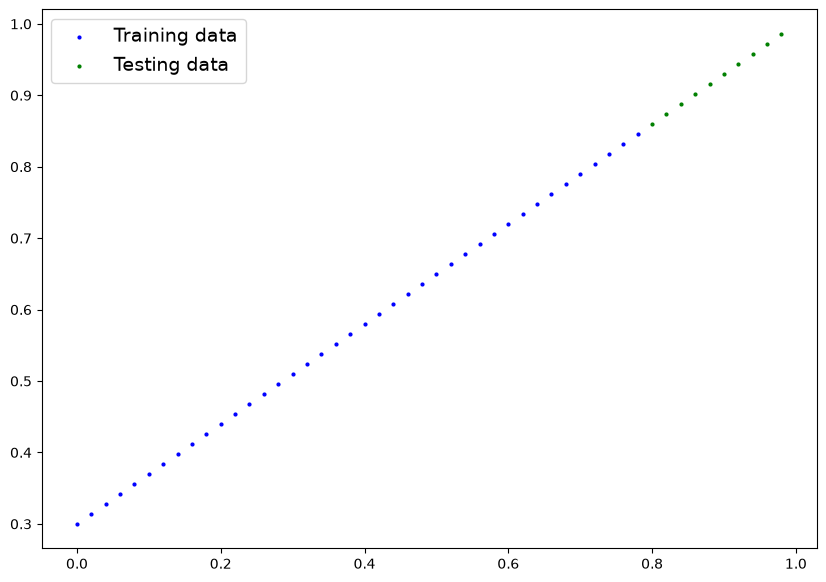

In [5]:
def plot_predictions(train_data, train_labels, test_data, test_labels, predictions=None):
    """
    Plots training data, test data and compares predictions.
    """
    plt.figure(figsize=(10, 7))
    # Plot training data in blue, test data in green, and predictions in red.
    plt.scatter(train_data, train_labels, c="b", s=4, label="Training data")
    plt.scatter(test_data, test_labels, c="g", s=4, label="Testing data")

    if predictions is not None:
        plt.scatter(test_data, predictions, c="r", s=4, label="Predictions")

    plt.legend(prop={"size": 14})
    plt.show()

plot_predictions(X_train, y_train, X_test, y_test)

## Building Model (Linear Regression)
1. Model flow ?
- Model starts with random values
- Adjust values to better fit to the weight/bais values.

2. Main algorithms
- Gradient descent
- Backpropagation

In [ ]:
# Linear regression model
class LinearRegressionModel(nn.Module): # nn.Module is the base class for all neural network modules in PyTorch
    def __init__(self):
        super().__init__()
        self.weights = nn.Parameter(torch.randn(1, # Start with a random weight and bias and adjust them during training to reach the optimal values.
                                                requires_grad=True, dtype=torch.float))
        self.bias = nn.Parameter(torch.randn(1, # Start with a random weight and bias and adjust them during training to reach the optimal values.
                                             requires_grad=True, dtype=torch.float))

    # The forward method defines the computation performed at every call.
    def forward(self, x: torch.Tensor) -> torch.Tensor: # x is the input tensor, and the method returns the output tensor after applying the linear transformation.
        return self.weights * x + self.bias # linear transformation: y = wx + b

## Video Timestamp
05:07:00